# Estudio dqdv y ajustes sobre NMC 45°C parte 1


In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [3]:
# --- carga de datos ---
nombre_dataset = 'NMC-45C-parte1-cada3'
path_json = f"../tmp/{nombre_dataset}.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 164


## Gráficos para observar dataset

In [4]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 163 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195, 198, 201, 204, 207, 210, 213, 216, 219, 222, 225, 228, 231, 234, 237, 240, 243, 246, 249, 252, 255, 258, 261, 264, 267, 270, 273, 276, 279, 282, 285, 288, 291, 294, 297, 300, 303, 306, 309, 312, 315, 318, 321, 324, 327, 330, 333, 336, 339, 342, 345, 348, 351, 354, 357, 360, 363, 366, 369, 372, 375, 378, 381, 384, 387, 390, 393, 396, 399, 402, 405, 408, 411, 414, 417, 420, 423, 426, 429, 432, 435, 438, 441, 444, 447, 450, 453, 456, 459, 462, 465, 468, 471, 474, 477, 480, 483, 486]


/home/mariajose/proc-icdv/src/plotting.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


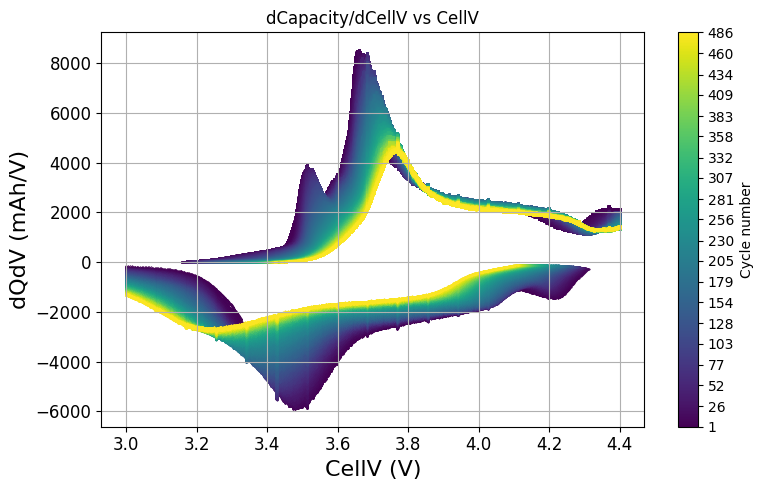

In [9]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep, 'Q', 'CellV')

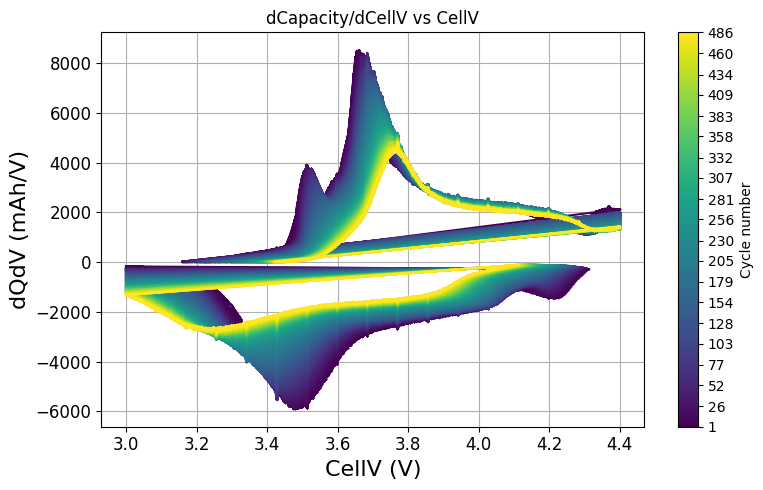

In [5]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep)


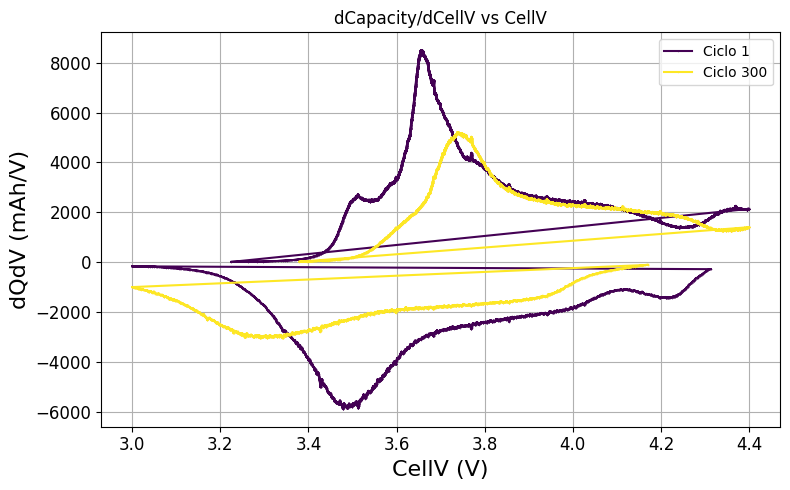

/home/mariajose/proc-icdv/src/plotting.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


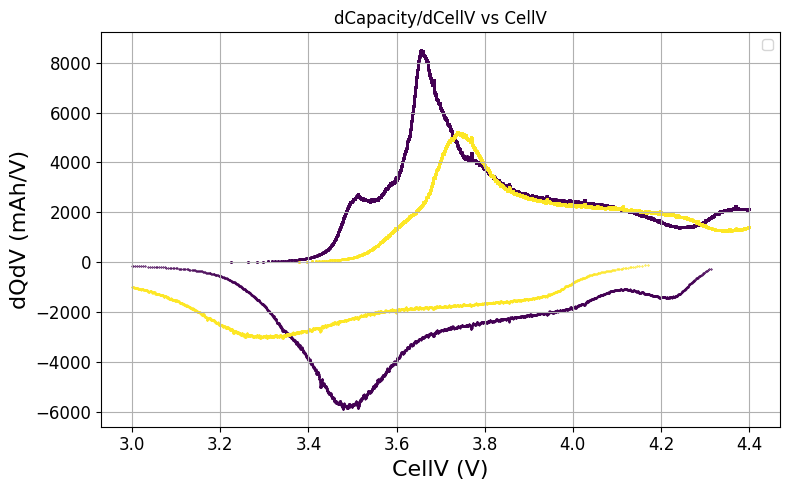

In [11]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos)) if i % 100 == 0]

pl.plot_n_cycles_dqdv(ciclos_sel_grafico, dict_ciclos_sep)

pl.plot_n_cycles_dqdv(ciclos_sel_grafico, dict_ciclos_sep, 'Q', 'CellV')

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


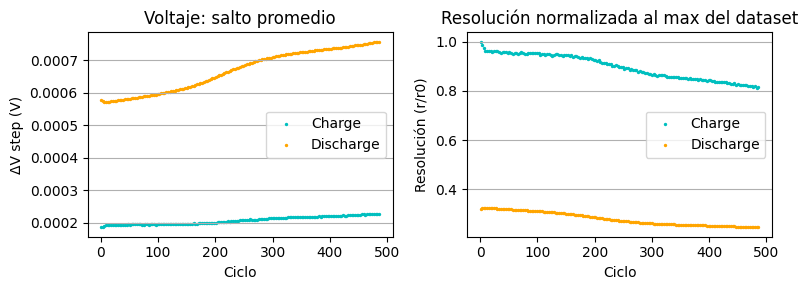

Puntos promedio por ventana de 2 mV:


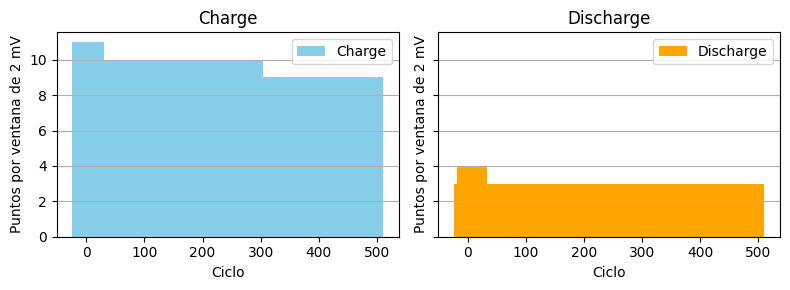

In [7]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

## Pruebo parametros filtros para calcular derivada

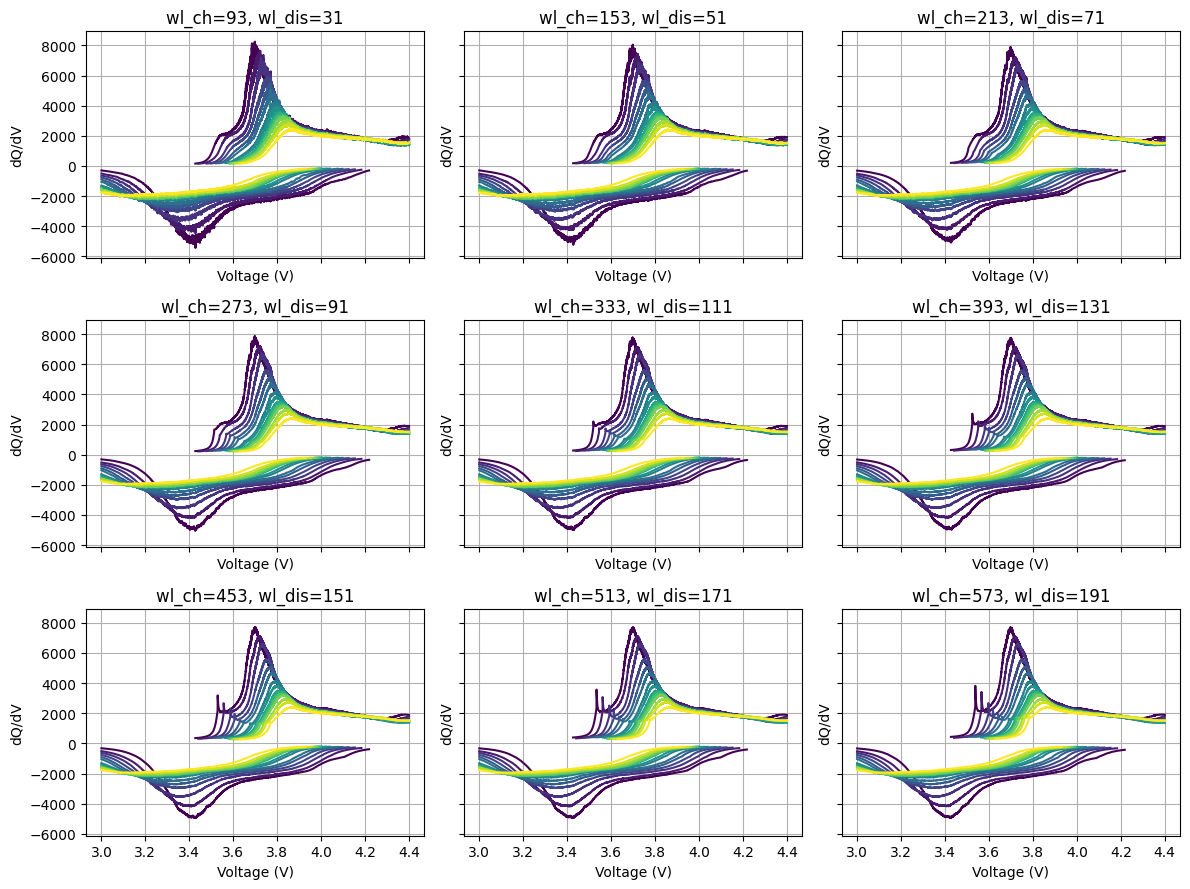

In [16]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[31,51,71,91,111,131,151,171,191], truncar_values=(10,30))

## Calculo derivada con los parámetros dados

> En este conjunto de datos, la señal de carga tiene **3 veces más resolución** que la de descarga.  
> Estos valores pueden cambiar según el dataset.  
>  
>  wl: tamaño ventana, 
>  
> **NMC-20**  
> • ch: (wl = 153, truncar los n=30 puntos iniciales)
> • dis: (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
>  
> **NMC-10**  
> • ch: (wl = 213, truncar los n=30 puntos iniciales)
> • dis: (wl = 71 = 153 / 3, truncar los n=10=30/3 puntos finales)

In [17]:
wl_ch = 153
wl_dis = 51
n_ch = 30
n_dis = 10

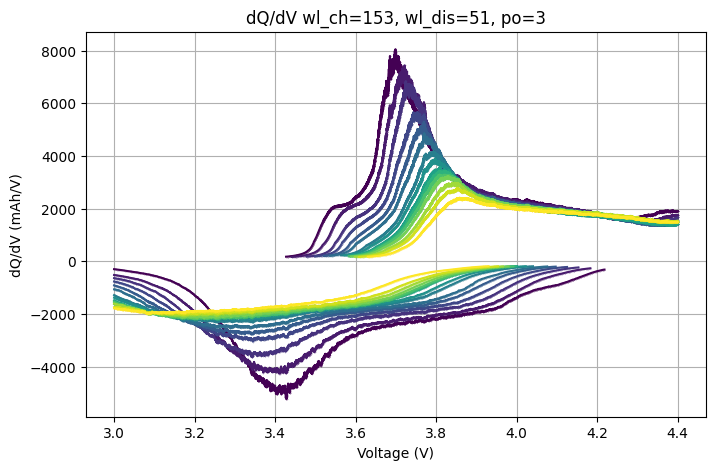

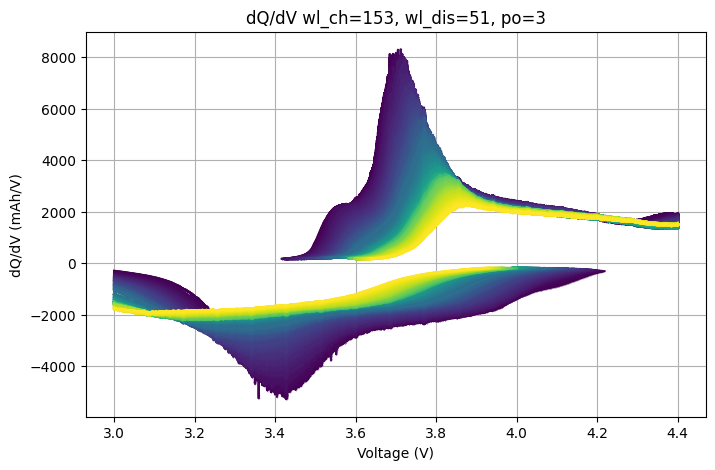

In [18]:
# --- Trunco datos y calculo derivada ---

diccio_grafico = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()}  for ciclo, df in dict_ciclos_sep.items()}
diccio_grafico = dr.truncar_señal(ciclos_sel_grafico, diccio_grafico, n_dis=n_dis, n_ch=n_ch)
diccio_grafico =  dr.plot_dqdV(ciclos_sel_grafico, diccio_grafico, wl_dis=wl_dis, wl_ch=wl_ch)

diccio_todos = {ciclo: {'Ch': df['Ch'].copy(), 'Dis': df['Dis'].copy()} for ciclo, df in dict_ciclos_sep.items()}
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=n_dis, n_ch=n_ch)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=wl_dis, wl_ch=wl_ch)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

# REALIZO AJUSTES

## Tests iniciales

> **NMC-20**

>param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828), # Formato: (amplitud, media, sigma, lambda)
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]

> **NMC-10**

>param_guess = [(1.18755445e+03, 3.66000000e+00, 7.35838350e-02, 3.22069806e+00),   # Formato: (amplitud, media, sigma, lambda)
                (5.50463062e+02, 3.71184186e+00, 1.56909614e-02, 1.01915550e+01),
                (1.24528665e+03, 4.20488376e+00, 2.44991919e-01, 5.07773895e+00)
                ]


In [19]:
# Indices de ciclos disponibles (todos):
# [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]

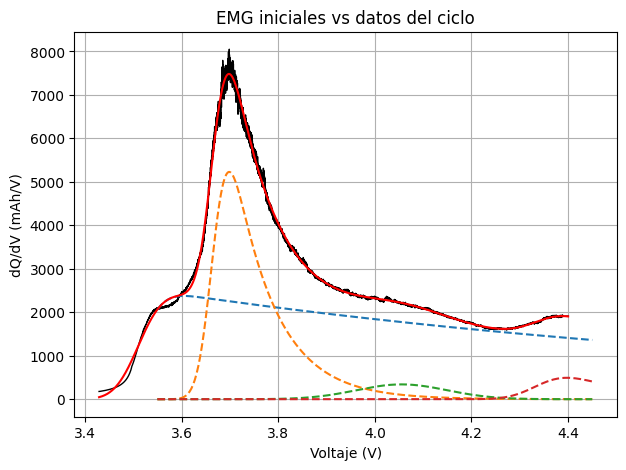

In [20]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

df_ch = diccio_todos[21]['Ch']
param_guess = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828), # Formato: (amplitud, media, sigma, lambda)
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]
ft.plot_emg_guess(df_ch, param_guess, x_range=(3.55, 4.45),legend=False)

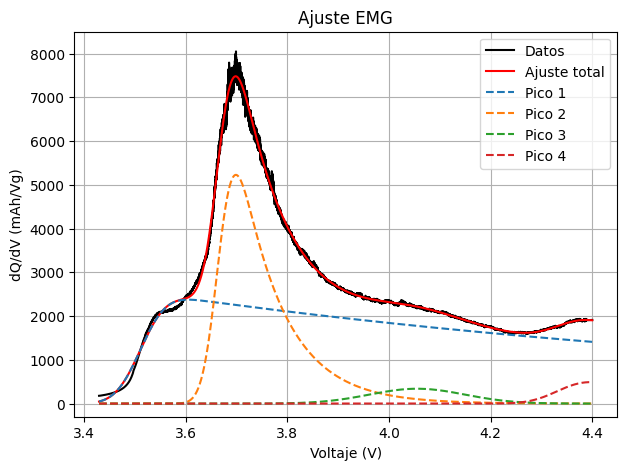

Parámetros optimizados ciclo 1 carga:
[3.82469269e+03 3.51145266e+00 3.93584993e-02 6.67218365e-01
 7.47805681e+02 3.66657683e+00 2.48857417e-02 1.15403813e+01
 7.99542107e+01 4.04228140e+00 9.29200614e-02 7.49903735e+01
 1.19528331e+02 4.34124870e+00 4.61740876e-02 7.16226390e+00]


In [47]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
p_ini_peaks = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828), # Formato: (amplitud, media, sigma, lambda)
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]
p_ini_peaks_flat = np.array(p_ini_peaks).flatten()
n_peaks = len(p_ini_peaks)

# Bounds de los parámetros
config_bounds = {
    'perc_a': 0.5,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 0.5,
    'perc_sigma': 0.5,
    'perc_lambda': 0.5,
    'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds)

# Ajuste del ciclo 21 de carga
df_ch_1 = diccio_todos[21]['Ch']
p_opt_1, cov_1 = ft.fit_emg_ciclo(df_ch_1, p_ini_peaks_flat, bounds_emg)
ft.plot_emg_fit(df_ch_1, p_opt_1)

print("Parámetros optimizados ciclo 1 carga:")
print(p_opt_1)

## Loop

In [36]:
timestamp = datetime.now(timezone(timedelta(hours=-3))).strftime("%Y-%m-%d_%H-%M-%S")

cfg_bounds: {'perc_a': 0.2, 'perc_mu': 0.2, 'perc_sigma': 0.2, 'perc_lambda': 0.2, 'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}}
----------------------------------------
Ajustando ciclo 21...


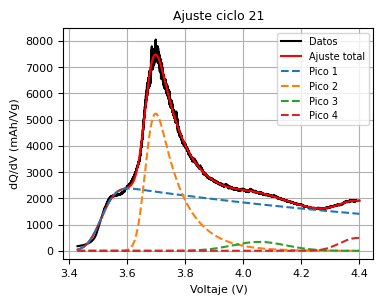

Ajustando ciclo 24...
Ajustando ciclo 27...
Ajustando ciclo 33...
Ajustando ciclo 36...
Ajustando ciclo 39...
Ajustando ciclo 42...
Ajustando ciclo 45...
Ajustando ciclo 48...
Ajustando ciclo 51...
Ajustando ciclo 54...
Ajustando ciclo 57...
Ajustando ciclo 60...


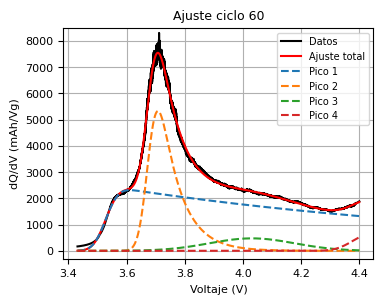

Ajustando ciclo 63...
Ajustando ciclo 66...
Ajustando ciclo 69...
Ajustando ciclo 72...
Ajustando ciclo 75...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


⚠️ Ajuste del ciclo 75 fallido: array must not contain infs or NaNs
Ajustando ciclo 78...
Ajustando ciclo 81...
⚠️ Ajuste del ciclo 81 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 84...
Ajustando ciclo 87...
Ajustando ciclo 90...
⚠️ Ajuste del ciclo 90 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 93...
Ajustando ciclo 96...
⚠️ Ajuste del ciclo 96 fallido: array must not contain infs or NaNs
Ajustando ciclo 99...
Ajustando ciclo 102...
⚠️ Ajuste del ciclo 102 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 105...
⚠️ Ajuste del ciclo 105 fallido: array must not contain infs or NaNs
Ajustando ciclo 108...
⚠️ Ajuste del ciclo 108 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 111...
Ajustando ciclo 114...
Ajustando ciclo 117...
Ajustando ciclo 120...


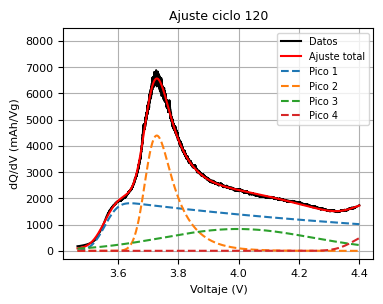

Ajustando ciclo 123...
⚠️ Ajuste del ciclo 123 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 126...
⚠️ Ajuste del ciclo 126 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 129...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 132...
⚠️ Ajuste del ciclo 132 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 135...
Ajustando ciclo 138...
⚠️ Ajuste del ciclo 138 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 141...
Ajustando ciclo 144...
⚠️ Ajuste del ciclo 144 fallido: array must not contain infs or NaNs
Ajustando ciclo 147...
Ajustando ciclo 150...
⚠️ Ajuste del ciclo 150 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 153...
⚠️ Ajuste del ciclo 153 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 156...
Ajustando ciclo 159...
⚠️ Ajuste del ciclo 159 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 162...
⚠️ Ajuste del ciclo 162 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 165...
Ajustando ciclo 168...
Ajustando ciclo 171...
⚠️ Ajuste del ciclo 171 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 174...
⚠️ Ajuste del ciclo 174 fa

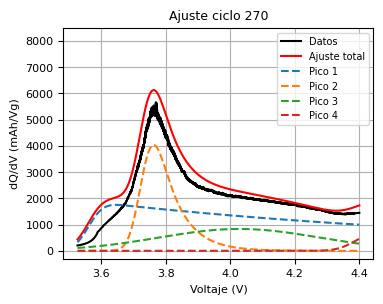

Ajustando ciclo 273...
⚠️ Ajuste del ciclo 273 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 276...
⚠️ Ajuste del ciclo 276 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 279...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 282...
⚠️ Ajuste del ciclo 282 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 285...
⚠️ Ajuste del ciclo 285 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 288...
Ajustando ciclo 291...
⚠️ Ajuste del ciclo 291 fallido: array must not contain infs or NaNs
Ajustando ciclo 294...
Ajustando ciclo 297...
Ajustando ciclo 300...
⚠️ Ajuste del ciclo 300 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 303...
⚠️ Ajuste del ciclo 303 fallido: array must not contain infs or NaNs
Ajustando ciclo 306...
Ajustando ciclo 309...
⚠️ Ajuste del ciclo 309 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 312...
Ajustando ciclo 315...
Ajustando ciclo 318...
Ajustando ciclo 321...
Ajustando ciclo 324...
Ajustando ciclo 327...
Ajustando ciclo 330...


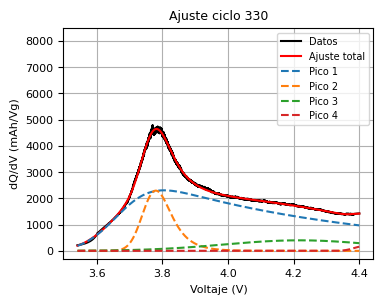

Ajustando ciclo 333...
Ajustando ciclo 336...
Ajustando ciclo 339...
Ajustando ciclo 342...
Ajustando ciclo 345...
Ajustando ciclo 348...
Ajustando ciclo 351...
Ajustando ciclo 354...
Ajustando ciclo 357...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


⚠️ Ajuste del ciclo 357 fallido: array must not contain infs or NaNs
Ajustando ciclo 360...
⚠️ Ajuste del ciclo 360 fallido: array must not contain infs or NaNs
Ajustando ciclo 363...
⚠️ Ajuste del ciclo 363 fallido: array must not contain infs or NaNs
Ajustando ciclo 366...
Ajustando ciclo 369...
Ajustando ciclo 372...
⚠️ Ajuste del ciclo 372 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 375...
Ajustando ciclo 378...
Ajustando ciclo 381...
⚠️ Ajuste del ciclo 381 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 384...
Ajustando ciclo 387...
⚠️ Ajuste del ciclo 387 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 390...


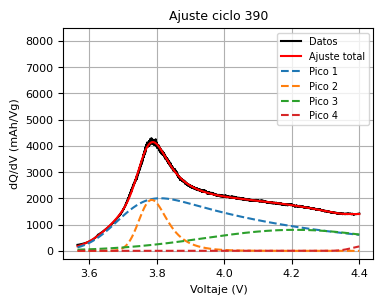

Ajustando ciclo 393...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 396...
⚠️ Ajuste del ciclo 396 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 399...
Ajustando ciclo 402...
⚠️ Ajuste del ciclo 402 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 405...
⚠️ Ajuste del ciclo 405 fallido: array must not contain infs or NaNs
Ajustando ciclo 408...
⚠️ Ajuste del ciclo 408 fallido: array must not contain infs or NaNs
Ajustando ciclo 411...
⚠️ Ajuste del ciclo 411 fallido: array must not contain infs or NaNs
Ajustando ciclo 414...
⚠️ Ajuste del ciclo 414 fallido: array must not contain infs or NaNs
Ajustando ciclo 417...
⚠️ Ajuste del ciclo 417 fallido: array must not contain infs or NaNs
Ajustando ciclo 420...
⚠️ Ajuste del ciclo 420 fallido: array must not contain infs or NaNs
Ajustando ciclo 423...
Ajustando ciclo 426...
⚠️ Ajuste del ciclo 426 fallido: array must not contain infs or NaNs
Ajustando ciclo 429...
⚠️ Ajuste del ciclo 429 fallido: array must not contain infs or NaNs
Ajustando ci

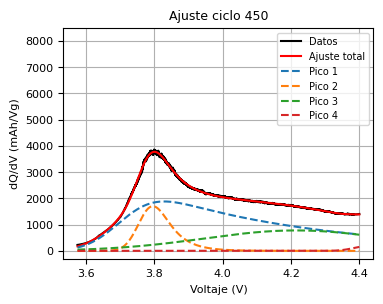

Ajustando ciclo 453...
⚠️ Ajuste del ciclo 453 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 456...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 459...
⚠️ Ajuste del ciclo 459 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 462...
⚠️ Ajuste del ciclo 462 fallido: array must not contain infs or NaNs
Ajustando ciclo 465...
Ajustando ciclo 468...
Ajustando ciclo 471...
⚠️ Ajuste del ciclo 471 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 474...
⚠️ Ajuste del ciclo 474 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 477...
⚠️ Ajuste del ciclo 477 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 480...


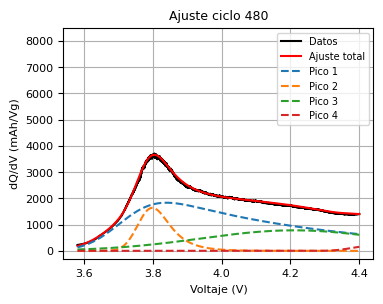

Ajustando ciclo 483...
⚠️ Ajuste del ciclo 483 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 486...
⚠️ Ajuste del ciclo 486 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 489...
⚠️ Ajuste del ciclo 489 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 492...


/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


⚠️ Ajuste del ciclo 492 fallido: array must not contain infs or NaNs
Ajustando ciclo 495...
⚠️ Ajuste del ciclo 495 fallido: array must not contain infs or NaNs
Ajustando ciclo 498...
⚠️ Ajuste del ciclo 498 fallido: array must not contain infs or NaNs
Ajustando ciclo 501...
⚠️ Ajuste del ciclo 501 fallido: array must not contain infs or NaNs
Ajustando ciclo 504...
⚠️ Ajuste del ciclo 504 fallido: array must not contain infs or NaNs
Ajustando ciclo 507...
⚠️ Ajuste del ciclo 507 fallido: array must not contain infs or NaNs
Ajustando ciclo 510...


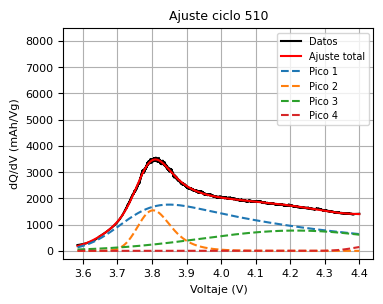

Ajustando ciclo 513...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 516...
⚠️ Ajuste del ciclo 516 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 519...
Ajustando ciclo 522...
⚠️ Ajuste del ciclo 522 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 525...
⚠️ Ajuste del ciclo 525 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 528...
Ajustando ciclo 531...
⚠️ Ajuste del ciclo 531 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 534...
⚠️ Ajuste del ciclo 534 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 537...
⚠️ Ajuste del ciclo 537 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 540...
⚠️ Ajuste del ciclo 540 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 543...
⚠️ Ajuste del ciclo 543 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 546...
Ajustando ciclo 549...
⚠️ Ajuste del ciclo 549 fallido: Residuals are not finite in the initial point.
Ajus

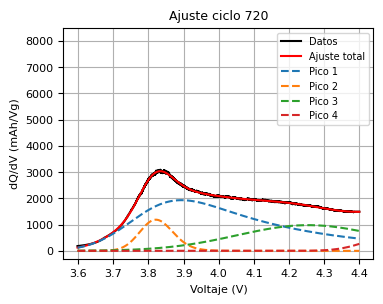

Ajustando ciclo 723...
Ajustando ciclo 726...
Ajustando ciclo 729...
Ajustando ciclo 732...
Ajustando ciclo 735...
Ajustando ciclo 738...
Ajustando ciclo 741...
Ajustando ciclo 744...
Ajustando ciclo 747...
Ajustando ciclo 750...


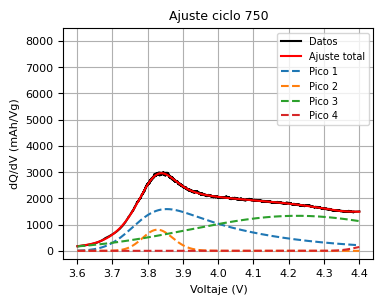

Ajustando ciclo 753...
Ajustando ciclo 756...
Ajustando ciclo 759...
Ajustando ciclo 762...
Ajustando ciclo 765...
Ajustando ciclo 768...
Ajustando ciclo 771...
Ajustando ciclo 774...
Ajustando ciclo 777...
Ajustando ciclo 780...


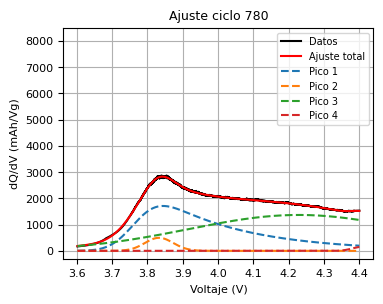

Ajustando ciclo 783...
Ajustando ciclo 786...
Ajustando ciclo 789...
Ajustando ciclo 792...
Ajustando ciclo 795...
Ajustando ciclo 798...
Ajustando ciclo 801...
Ajustando ciclo 804...
Ajustando ciclo 807...
Ajustando ciclo 810...


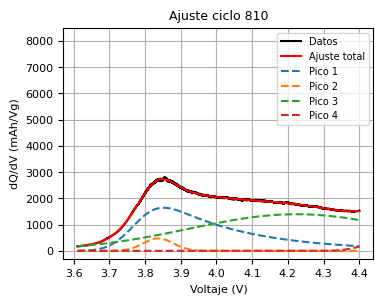

Ajustando ciclo 813...
Ajustando ciclo 816...
Ajustando ciclo 819...
Ajustando ciclo 822...
Ajustando ciclo 825...
Ajustando ciclo 828...
Ajustando ciclo 831...
Ajustando ciclo 834...
Ajustando ciclo 837...
Ajustando ciclo 840...


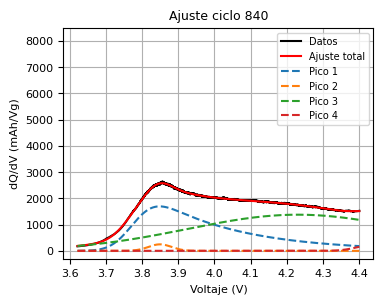

Ajustando ciclo 843...
Ajustando ciclo 846...


/home/mariajose/proc-icdv/src/fitting.py:44: RuntimeWarning: overflow encountered in exp
  np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: overflow encountered in multiply
  y += (a * (lambd/2) *
/home/mariajose/proc-icdv/src/fitting.py:43: RuntimeWarning: invalid value encountered in multiply
  y += (a * (lambd/2) *


Ajustando ciclo 849...
Ajustando ciclo 852...
Ajustando ciclo 855...
⚠️ Ajuste del ciclo 855 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 858...
Ajustando ciclo 861...
Ajustando ciclo 864...
Ajustando ciclo 867...
Ajustando ciclo 870...
⚠️ Ajuste del ciclo 870 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 873...
⚠️ Ajuste del ciclo 873 fallido: Residuals are not finite in the initial point.
Ajustando ciclo 876...
Ajustando ciclo 879...
Ajustando ciclo 882...
⚠️ Ajuste del ciclo 882 fallido: array must not contain infs or NaNs
Ajustando ciclo 885...
Ajustando ciclo 888...
Ajustando ciclo 891...
Ajustando ciclo 894...
✅ Ajustes terminados. Resultados guardados en '../output/parametros_ajustes_NMC-20_EMG_2025-11-28_17-51-08.csv'


In [48]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop, nombre del .csv, parámetros iniciales y bounds ------------------
nombre_ajuste = f'{nombre_dataset}_EMG_{timestamp}'
ciclos_ajustar = [c for c in ciclos_sel_todos] #if 0 <= c <= 900]
ciclos_graficar = [c for c in ciclos_ajustar if c == 21 or c % 10 == 0]


# Parámetros iniciales por pico
p_ini_peaks = [(3814.876992578531,3.511462387968619,0.03937649023787247,0.6691095124684828), # Formato: (amplitud, media, sigma, lambda)
               (747.9674505882472,3.666574425627915,0.024883050612290222,11.536277795861313),
               (80.48153481362431,4.036148935044482,0.09212835375737331,49.99999989793321),
               (120.28718521872311,4.3411875947661995,0.04625798093742598,7.141221047103965)]

p_ini_peaks_flat = np.array(p_ini_peaks).flatten() # aplanado
n_peaks = len(p_ini_peaks)

# Bounds de los parámetros 1er ajuste
config_bounds = {
    'perc_a': 0.2,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 0.2,
    'perc_sigma': 0.2,
    'perc_lambda': 0.2,
    'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg_ini = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds_ini)

# Bounds de los parámetros demás ajustes
config_bounds_loop = {
    'perc_a': 0.9,           # porcentaje de variación permitido para la amplitud
    'perc_mu': 0.9,
    'perc_sigma': 0.9,
    'perc_lambda': 0.9,
    'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}      # restricción de rango
}
bounds_emg_loop = ft.construir_bounds(p_ini_peaks_flat, n_peaks, config_bounds_loop)
# ----------------------------------------------------------------------------------------------

parametros, covs = ft.fitloop_emg(
    diccio_todos,
    ciclos=ciclos_ajustar,
    p_ini_emg=p_ini_peaks_flat,
    bounds_ini_emg=bounds_emg_ini,
    ciclos_grafico=ciclos_graficar,
    cfg_bounds=config_bounds
)

df_parametros = ft.guardar_parametros_emg(parametros, ciclos_sel_todos, nombre_ajuste)

# Ploteo datos ya ajustados

In [49]:
# --- Trabajo con parámetros previamente ajustados ---

archivo = "../output/parametros_ajustes_NMC-20_EMG_2025-11-28_17-51-08.csv"

df_param = pd.read_csv(archivo, index_col=0)
df_param.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,3820.896469,3.511456,0.039365,0.667949,747.870502,3.666576,0.024885,11.538713,80.155958,4.039164,0.092536,59.999998,120.013300,4.341189,0.046192,7.133734
24,3945.022411,3.509705,0.031492,0.614332,766.209449,3.664416,0.029149,11.715121,95.337247,4.017511,0.111043,47.999999,101.538852,4.336361,0.040953,8.560481
27,4006.518272,3.515894,0.037791,0.631331,701.978293,3.667818,0.024673,13.781417,114.404696,3.974635,0.127606,57.599998,81.231082,4.346309,0.032763,8.455274
33,3456.660009,3.517570,0.037694,0.757597,710.002620,3.670289,0.024906,12.437360,124.095340,4.011981,0.125747,69.119998,97.477298,4.355978,0.039064,10.146328
36,3337.277943,3.514774,0.030924,0.752036,744.564640,3.669897,0.026623,12.283043,148.788131,4.050381,0.128047,82.940091,116.965714,4.363240,0.046870,11.409553


## Gráfico de un ciclo en particular

In [50]:
# --- Plot de un ciclo en particular ---

# ------ Elegir cuál y de qué loop ---------------
ciclo = 45
df_param = pd.read_csv(archivo, index_col=0)
nombre = nombre_dataset # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio_todos[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

#ft.plot_emg_fit(df_ch_i, popt_i, save_path=f'../output/ajuste_C{ciclo}_{nombre}.png', nombre_ciclo=ciclo)

## Evolución parámetros

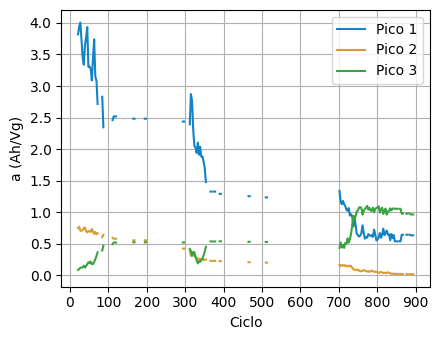

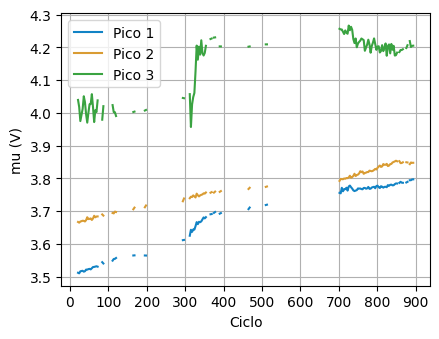

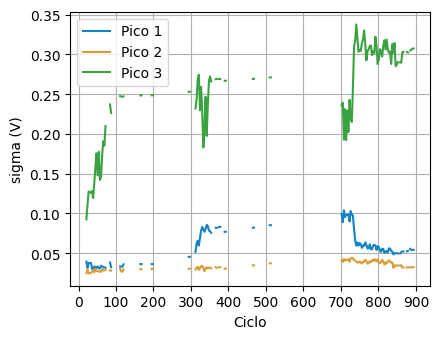

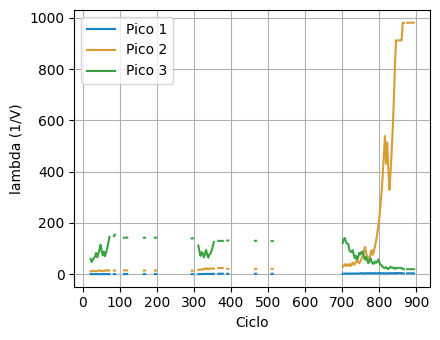

In [51]:
# ------ Elegir de qué loop ---------------
df_params = pd.read_csv(archivo, index_col=0)
nombre = nombre_dataset # etiqueta gráfico
# ------------------------------------------------

#print(df_params.index)
n_peaks = 3

# Graficar todos los parámetros
for p in ['a', 'mu', 'sigma', 'lambda']:
    ft.plot_param_evolution(df_params, p, n_peaks, nombre, exclude_peaks=[])